Image loaded successfully


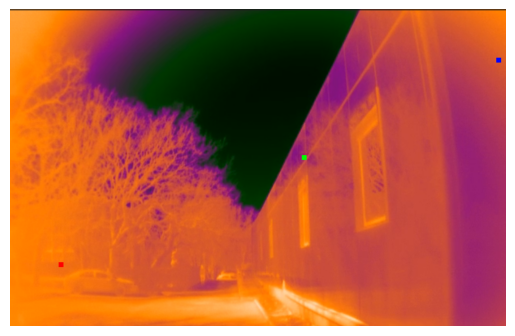

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "images/thermal_image_1.png"
img = cv2.imread(image_path)

if img is not None:
    print("Image loaded successfully")
else:
    print("Image not found")

# changing 10x10 regions
img2 = img.copy()
img2[100:110, 1000:1010] = [255, 0, 0]
img2[300:310, 600:610] = [0, 255, 0]
img2[520:530, 100:110] = [0, 0, 255]

plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB) ,vmin=0, vmax=255)
plt.axis('off')
plt.show()

In [7]:
roi = img[190:460, 700:800]
success = cv2.imwrite("outputs/window_roi.jpg", roi)
print("Saved: ", success)

Saved:  True


Width:  1020
Height:  651


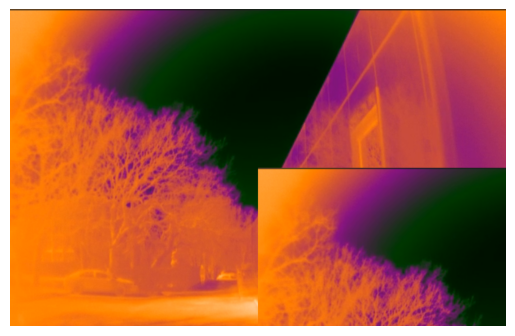

In [11]:
# Copy and paste a region
# copy the top-left part of the image and paste it into the bottom-right part

height, width = img.shape[:2]
print("Width: ", width)
print("Height: ", height)
upper_left = img[0 : height // 2, 0 : width // 2]
result = img.copy()
result[height // 2 + 1 : height, width // 2 : width] = upper_left

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB) ,vmin=0, vmax=255)
plt.axis('off')
plt.show()

In [ ]:
# Draw on image using OpenCV functions
img_draws = img.copy()
height, width = img_draws.shape[:2]
print("Width: ", width)
print("Height: ", height)

# cv2.rectangle(image, top_left (x,y), bottom_right (x,y), color BGR, thickness)
# thickness=-1 fills the rectangle
cv2.rectangle(img_draws, (width // 2, height // 2 + 1), (width, height), (0, 0, 255), 2)
cv2.rectangle(img_draws, (700, 190), (800, 460), (0, 255, 0), -1)

# cv2.circle(image, center (x,y), radius, color BGR, thickness)
# thickness=-1 fills the circle
cv2.circle(img_draws, (width // 2, height //2), 50, (255, 0, 0), 2)
cv2.circle(img_draws, (width // 2, height //2), 50, (255, 0, 0), 2)

# cv2.line(image, start (x,y), end (x,y), color BGR, thickness)
cv2.line(img_draws, (0, height // 2), (width // 2 + 1, 0), (0, 255, 255), 2)

# cv2.putText(image, text, origin (x,y), font, font_scale, color BGR, thickness)
# origin is the bottom-left corner of the text
cv2.putText(img_draws, "ROI", (700, 180), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

plt.imshow(cv2.cvtColor(img_draws, cv2.COLOR_BGR2RGB) ,vmin=0, vmax=255)
plt.axis('off')
plt.show()

success = cv2.imwrite("outputs/thermal_with_drawings.jpg", img_draws)
print("Saved: ", success)